An exploration where we test different models and tune them in order to find the best one that we finally use in this project.

We'll test logistic regression, random forest and XGBoost.
My initial guess is that Random forest will perform best out of the box. relationships seem non linear which is to logistic regressions disadvantage. 

In [ ]:
# Libraries:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

import sqlite3
import os
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import shap

/home/arash/Desktop/churn_pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# path to database
db_path = os.path.join('..', 'Database', 'churn_database.db')

# querying the cleaned data
conn = sqlite3.connect(db_path)
df_cleaned = pd.read_sql("SELECT * FROM prd_churn_cleaned", conn)
conn.close()

# defining Features (X) and Target (y)
X = df_cleaned.drop('Exited', axis=1)
y = df_cleaned['Exited']

# splitting the data 80/20 (train/test)
# using stratify=y to keep the 80/20 churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"training rows: {len(X_train)}, Testing rows: {len(X_test)}")

training rows: 8000, Testing rows: 2000


In [3]:
# models we'll test
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# looping though each model and printing their scores
results = []
for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

# creating dataFrame for viewing
comparison_df = pd.DataFrame(results)
print(comparison_df)

/home/arash/Desktop/churn_pipeline/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model        F1       AUC
0  Logistic Regression  0.317518  0.759379
1        Random Forest  0.602740  0.862944
2              XGBoost  0.589888  0.850972


As believed, RF and XGBoost did way better on this data than the logistic regression model. moving forward, we will tune RF and XGBoost to see if we get a difference. However, we did not use any scaling in the preprocess.py, which would have benefited the logistic model slightly hence resulting in better figures.

In [ ]:
rf_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    param_distributions=rf_grid, 
    n_iter=10, 
    cv=3, 
    scoring=['f1', 'roc_auc'], # looking at both metrics
    refit='f1',                # choosing the "Best" based on F1
    random_state=42, 
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

# pulling the results for the best model found
best_index = rf_search.best_index_
best_auc = rf_search.cv_results_['mean_test_roc_auc'][best_index]

print(f"Best RF F1 (Opt): {rf_search.best_score_:.4f}")
print(f"ROC-AUC: {best_auc:.4f}")
print(f"Best RF Params: {rf_search.best_params_}")

Best RF F1 (Opt): 0.6143
ROC-AUC: 0.8570
Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10, 'class_weight': 'balanced'}


Model Tuning & Optimization
Used RandomizedSearchCV to optimize the Random Forest for the minority class (churners).

- Result: F1-score improved to 0.6143, while ROC-AUC slightly adjusted to 0.8570.

- Justification: Prioritized F1-score over ROC-AUC to better handle class imbalance. This ensures a better balance between Precision (avoiding false alarms) and Recall (capturing actual churners) for the dashboard.

In [ ]:
# grid
xgb_grid = {
    "n_estimators": [100, 200, 500],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 8],
    "scale_pos_weight": [1, 4],
}

# getting rid of warnings below
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# search
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        device="cuda",          # activated CUDA acceleration running on GPU
        tree_method="hist",      # Required for GPU optimization in XGBoost
        eval_metric="logloss",
        random_state=42,
    ),
    param_distributions=xgb_grid,
    n_iter=15,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=1,                    # Left at 1 to prevent CUDA thread collision
)

xgb_search.fit(X_train, y_train)

print(f"Best XGB F1: {xgb_search.best_score_:.4f}")
print(f"Best XGB Params: {xgb_search.best_params_}")

Best XGB F1: 0.6035
Best XGB Params: {'scale_pos_weight': 4, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.01}


as we see it proves that "newer/more complex" isn't always "better." For this specific 10k-row dataset, the simpler "Bagging" logic of RF is better than the "Boosting" logic of XGBoost.

Now we have F1 scores:

- RF: 0.6143
- XGBoost: 0.6035

I.e. we're going with RF.

/tmp/ipykernel_5806/464554204.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


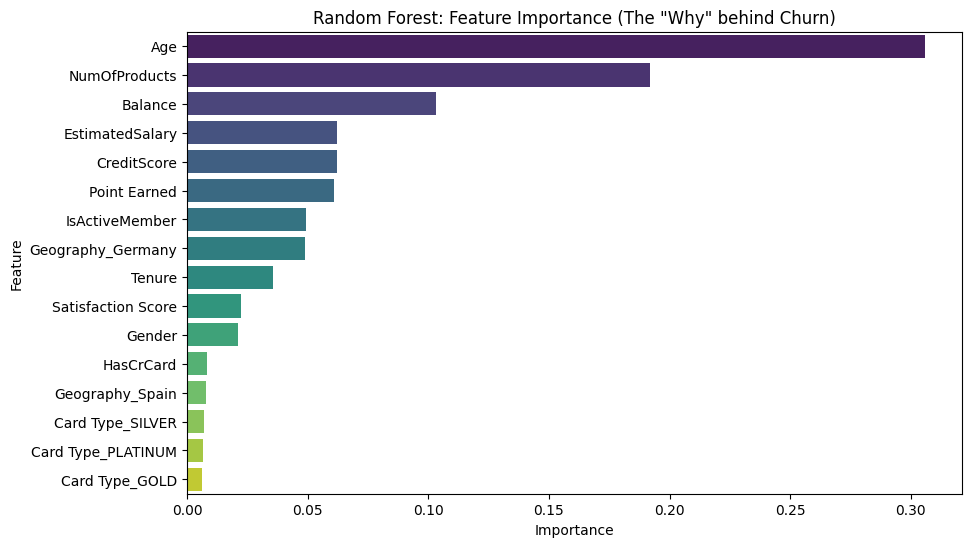

In [ ]:
# get the best RF model
best_rf = rf_search.best_estimator_

# creating a dataframe of feature importances
features = X.columns
importances = best_rf.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest: Feature Importance (The "Why" behind Churn)')
plt.show()

I relied on the Random Forest's inherent ability to perform non-linear splitting on continuous variables like Age and Balance.

- one idea could be to feature engineer this further by dividing some of the variables into brackets for instance

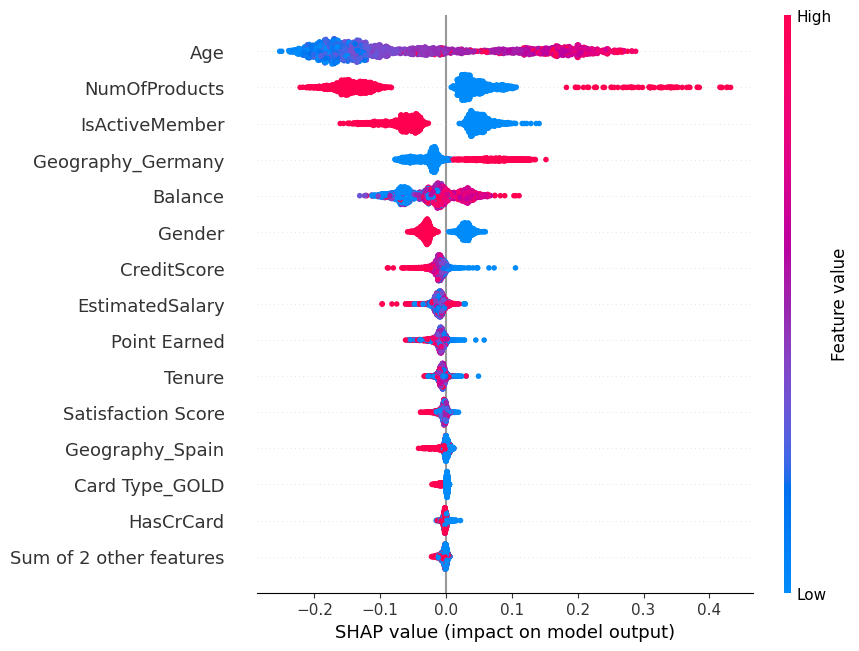

In [ ]:
# preparing explainer
explainer = shap.TreeExplainer(best_rf)

# calculating values
shap_values = explainer(X_test)

# handling multi-class output formats for Random Forest
if len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

# generating the plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_class1, max_display=15)

SHAP Interpretation: (lower value on x-axis means lower risk of churn while higher means higher risk)

While global feature importance identified which variables drove the model's decisions, the SHAP summary plot exposes the exact directionality and non-linear thresholds of these effects:

- Age: Demonstrates a direct positive correlation with churn risk. Older demographics present the highest risk.

- NumOfProducts (Non-Linear Relationship):
The SHAP distribution suggests a non-linear relationship between product holdings and churn probability. Customers with moderate product adoption appear associated with lower churn risk, while both low and very high product counts contribute positively toward churn predictions. This aligns with aggregate churn analysis, where customers holding two products demonstrated the highest retention rates.

- Engagement: Inactivity (IsActiveMember = 0) serves as a primary leading indicator of customer defection.
